In [1]:
import logging

import os
import sys

import sys
sys.path.insert(0, '../../desilike')
sys.path.insert(0, '../../desi-clustering')

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

# disable jax warning:profiler.profiles
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
import lsstypes
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

from tools import read_data, rebin_data, get_observable_and_likelihood, run_profiler, run_mcmc, plot_triangle, plot_observables

root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
#root = '/Users/edmond/Work/data/desi-clustering/' 

data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[000000.00] [0/1] 06-28 08:10  FIT PNG                   INFO     Load data from: /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/local_png/base/


In [3]:
def propose_fiducial():
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmax': 0.08, 'kmax_ell2': 0.08}
    
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmax': 0.08, 'kmax_ell2': 0.08}

    return propose_fiducial

fiducial = propose_fiducial()

[000000.03] [0/1] 06-28 08:10  PNG fitting tools         INFO     Reading the data with weight_type='default-fkp-oqe' from /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/mesh2_spectrum_poles_LRG_z0.4-1.1_GCcomb_weight-default-fkp-oqe.h5
[000000.05] [0/1] 06-28 08:10  PNG fitting tools         INFO     Reading the window with tracer_window='LRG', weight_type='default-fkp-oqe',window_extra='' from /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/window_mesh2_spectrum_poles_LRG_z0.4-1.1_GCcomb_weight-default-fkp-oqe.h5
[000000.26] [0/1] 06-28 08:10  PNG fitting tools         INFO     Reading nmocks=1000 for tracer='LRG' with tracer_mocks='LRG' weight_type_mocks='default-fkp-oqe'.
[000009.28] [0/1] 06-28 08:10  FIT PNG                   INFO     Running rebinning with kpivot=[0.1] and nrebin=[1]
[000012.73] [0/1] 06-28 08:10  FIT PNG             

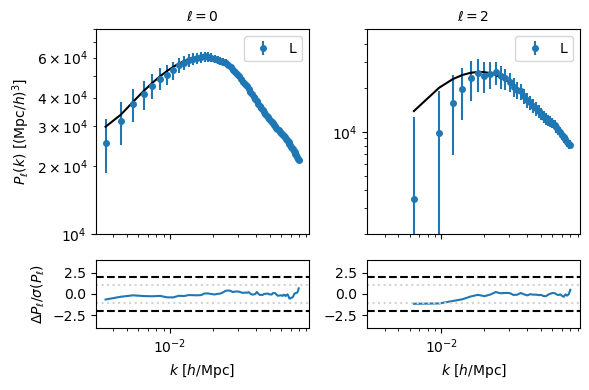

[000050.36] [0/1] 06-28 08:11  ObservablesGaussianLikelihood INFO     Covariance matrix with 114 points built from 1000 observations.
[000050.36] [0/1] 06-28 08:11  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.8849.
[000050.36] [0/1] 06-28 08:11  ObservablesGaussianLikelihood INFO     Covariance matrix with 114 points and 4 parameters built from 1000 observations.
[000050.36] [0/1] 06-28 08:11  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.1182.
[000050.38] [0/1] 06-28 08:11  EnsembleSampler           INFO     Varied parameters: ['LRG_ell0.b1', 'LRG_ell0.sigmas', 'LRG_ell0.sn0', 'fnl_loc']
[000050.39] [0/1] 06-28 08:11  EnsembleSampler           INFO     Samples will be written to: tmp
[000080.06] [0/1] 06-28 08:11  Emcee                     INFO     total likelihood evaluations: 319984
[000080.19] [0/1] 06-28 08:11  EnsembleSampler           INFO     Diagnostics:
[000080.39] [0/1] 06-28 08:11  EnsembleSampler   

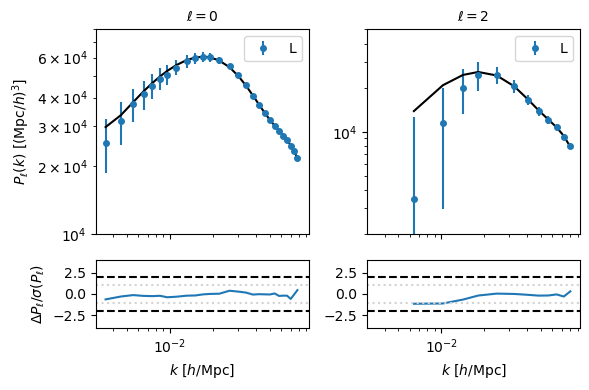

[000109.77] [0/1] 06-28 08:12  ObservablesGaussianLikelihood INFO     Covariance matrix with 39 points built from 1000 observations.
[000109.78] [0/1] 06-28 08:12  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9600.
[000109.78] [0/1] 06-28 08:12  ObservablesGaussianLikelihood INFO     Covariance matrix with 39 points and 4 parameters built from 1000 observations.
[000109.78] [0/1] 06-28 08:12  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0312.
[000109.80] [0/1] 06-28 08:12  EnsembleSampler           INFO     Varied parameters: ['LRG_ell0.b1', 'LRG_ell0.sigmas', 'LRG_ell0.sn0', 'fnl_loc']
[000109.80] [0/1] 06-28 08:12  EnsembleSampler           INFO     Samples will be written to: tmp
[000135.98] [0/1] 06-28 08:12  Emcee                     INFO     total likelihood evaluations: 319984
[000136.05] [0/1] 06-28 08:12  EnsembleSampler           INFO     Diagnostics:
[000136.27] [0/1] 06-28 08:12  EnsembleSampler     

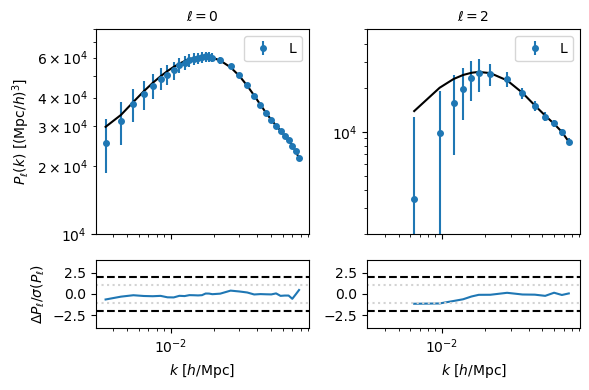

[000166.16] [0/1] 06-28 08:13  ObservablesGaussianLikelihood INFO     Covariance matrix with 46 points built from 1000 observations.
[000166.16] [0/1] 06-28 08:13  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9530.
[000166.16] [0/1] 06-28 08:13  ObservablesGaussianLikelihood INFO     Covariance matrix with 46 points and 4 parameters built from 1000 observations.
[000166.16] [0/1] 06-28 08:13  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0387.
[000166.19] [0/1] 06-28 08:13  EnsembleSampler           INFO     Varied parameters: ['LRG_ell0.b1', 'LRG_ell0.sigmas', 'LRG_ell0.sn0', 'fnl_loc']
[000166.19] [0/1] 06-28 08:13  EnsembleSampler           INFO     Samples will be written to: tmp
[000194.01] [0/1] 06-28 08:13  Emcee                     INFO     total likelihood evaluations: 319984
[000194.06] [0/1] 06-28 08:13  EnsembleSampler           INFO     Diagnostics:
[000194.26] [0/1] 06-28 08:13  EnsembleSampler     

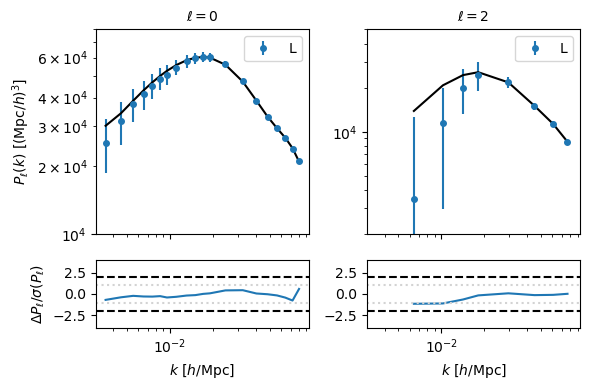

[000222.89] [0/1] 06-28 08:14  ObservablesGaussianLikelihood INFO     Covariance matrix with 28 points built from 1000 observations.
[000222.89] [0/1] 06-28 08:14  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9710.
[000222.89] [0/1] 06-28 08:14  ObservablesGaussianLikelihood INFO     Covariance matrix with 28 points and 4 parameters built from 1000 observations.
[000222.89] [0/1] 06-28 08:14  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0195.
[000222.91] [0/1] 06-28 08:14  EnsembleSampler           INFO     Varied parameters: ['LRG_ell0.b1', 'LRG_ell0.sigmas', 'LRG_ell0.sn0', 'fnl_loc']
[000222.91] [0/1] 06-28 08:14  EnsembleSampler           INFO     Samples will be written to: tmp
[000248.58] [0/1] 06-28 08:14  Emcee                     INFO     total likelihood evaluations: 319984
[000248.64] [0/1] 06-28 08:14  EnsembleSampler           INFO     Diagnostics:
[000248.84] [0/1] 06-28 08:14  EnsembleSampler     

In [4]:
tracer = 'LRG' # 'QSO'
kmin = 3e-3

pk, window, _, mocks = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, 
                                 window_extra='', weight_type_mocks='default-fkp-oqe', **fiducial[tracer])
 
pk = lsstypes.mean(mocks[:50])

zeffs = {}
zeffs['LRGxLRG'] = {ell: window.observable.get(ell).attrs['zeff'] for ell in pk.ells}


chains = []
for kpivot, nrebin in zip([[1e-1], [1e-2, 2e-2], [2e-2], [1e-2, 2e-2]], [[1], [2,2], [4], [2, 4]]):
    logger.info(f'Running rebinning with kpivot={kpivot} and nrebin={nrebin}')

    pk_t, window_t, _, mocks_t = rebin_data(pk, window, None, mocks, tracer=tracer, kpivot=kpivot, nrebin=nrebin, kmin=kmin, kmin_ell2=kmin, **fiducial[tracer])
    try: 
        logger.info(f'After rebinning and k range selection: {pk_t.get(0).k.shape[0]} and {pk_t.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk_t.get(0).k.shape[0]} data points.')

    observable, likelihood = get_observable_and_likelihood(pk_t, window_t, mocks_t, tracer, zeffs, engine='camb')
    profiler = run_profiler(likelihood)
    plot_observables({tracer: observable})
    sampler = run_mcmc(likelihood, max_steps=20000, check_every=20000)

    from desilike.samples import MCSamples
    burnin, thin = 0.2, 50

    chains.append(MCSamples.concatenate([chain.remove_burnin(burnin)[::thin] for chain in sampler.chains]))
    #print(chains.to_stats(tablefmt="pretty"))

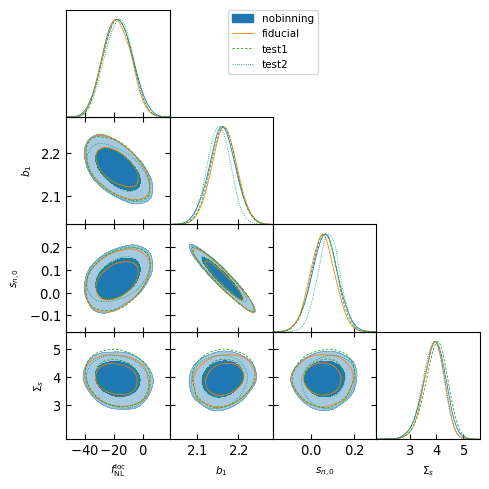

+-----------------+--------+-------+--------+-------+-----------------+-----------------+
|                 | argmax | mean  | median |  std  | quantile:1sigma | interval:1sigma |
+-----------------+--------+-------+--------+-------+-----------------+-----------------+
|   LRG_ell0.b1   | 2.159  | 2.161 | 2.161  | 0.032 |  +0.032/-0.032  |  +0.031/-0.033  |
| LRG_ell0.sigmas |  4.00  | 3.91  |  3.93  | 0.44  |   +0.43/-0.43   |   +0.49/-0.35   |
|  LRG_ell0.sn0   | 0.068  | 0.064 | 0.066  | 0.061 |  +0.060/-0.060  |  +0.061/-0.058  |
|     fnl_loc     | -15.9  | -17.2 | -17.3  |  9.9  |    +10./-10.    |   +9.4/-10.7    |
+-----------------+--------+-------+--------+-------+-----------------+-----------------+
+-----------------+--------+-------+--------+-------+-----------------+-----------------+
|                 | argmax | mean  | median |  std  | quantile:1sigma | interval:1sigma |
+-----------------+--------+-------+--------+-------+-----------------+-----------------+
|   LRG_el

In [5]:
params = ['fnl_loc', 'LRG_ell0.b1', 'LRG_ell0.sn0', 'LRG_ell0.sigmas']
xlabels = [r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$']
plot_triangle(chains, params, legend_labels=['nobinning', 'fiducial', 'test1', 'test2'], xlabels=xlabels, 
            filled=True, contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '--', ':'])

for cc in chains:
    print(cc.to_stats(tablefmt="pretty"))